Task2 GINO model: particle states at any time t to Eulerian velocity/vorticity field

`neuralop.models.GINO`. The learned map is from a variable-size Lagrangian particle cloud to fixed Eulerian query points, with targets `[U_x, U_y, U_z, W_x, W_y, W_z]`.

Important design checks carried over from Task1-v2:
- low-information/redundant input channels removed (`geom_body_near`, `freestream_x`, `freestream_z`);
- normalization statistics come only from the training split;
- validation includes a same-distribution split from training cases plus held-out-angle cases when available;
- training uses gradient accumulation, AMP when CUDA is available, clipping, and a best-checkpoint save in `results/`.

Is the train data having strides or random choice at every epoch or some situation?
for epoch in range(1, settings['epochs'] + 1):
    epoch_start_time = time.time()
    model.train()
    particle_cap = particle_cap_for_epoch(epoch)
    accumulation_steps = max(int(settings.get('gradient_accumulation_steps', 1)), 1)

    if training_frame_selection == 'all_frames':
        chosen_training_indices = np.arange(len(training_dataset), dtype=np.int64)
        np.random.default_rng(SEED + epoch).shuffle(chosen_training_indices)

this is what i meant...


Task2: Learning the map from the evolution of states of particle to the velocity and vorticity field in an Eulerian Grid. This again is computed using Biot-Savart inegral operator, which is what is learned.


Task2 requires a novel architecture to map from the Lagrangian field to an Eulerian field. Hence, usage of GNO combined with FNO helps capture global features in the spectral domain and at the same time allows features of GNN.

In [13]:
from pathlib import Path
import json
import math
import random
import time
import inspect
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader

try:
    from neuralop.models import GINO
    GINO_IMPORT_ERROR = None
except Exception as error:
    GINO = None
    GINO_IMPORT_ERROR = error
    print('[warn] neuralop.models.GINO could not be imported in this kernel.')
    print('       Install NeuralOperator in the active Jupyter environment with: pip install neuraloperator')

try:
    from neuralop.utils import count_model_params
except Exception:
    def count_model_params(model):
        return sum(p.numel() for p in model.parameters())
    

import torch

# print(torch.__version__)
# print(torch.version.cuda)
# print(torch.cuda.is_available())

In [15]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

current_directory = Path.cwd().resolve()

if (current_directory / 'final-2').is_dir():
    REPO_ROOT = current_directory
    FINAL_DIR = current_directory / 'final-2'
elif current_directory.name == 'final-2':
    FINAL_DIR = current_directory
    REPO_ROOT = current_directory.parent
elif current_directory.parent.name == 'final-2':
    FINAL_DIR = current_directory.parent
    REPO_ROOT = current_directory.parent.parent
else:
    REPO_ROOT = current_directory
    FINAL_DIR = current_directory / 'final-2'

OUTPUT_DIR = FINAL_DIR / 'processed_data_task2'
RESULTS_DIR = REPO_ROOT / 'result' / 'task2'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = OUTPUT_DIR / 'task2_gino_dataset.npz'
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f'Missing {DATASET_PATH}. Run `python3 final-2/preprocess_data_task2.py` from the repo root, '
        f'or `python3 preprocess_data_task2.py` from final-2.'
    )

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Repo root:', REPO_ROOT)
print('Final dir.:', FINAL_DIR)
print('Dataset  :', DATASET_PATH)
print('Results  :', RESULTS_DIR)
print('Device   :', DEVICE)

if DEVICE.type == 'cuda':
    print('GPU      :', torch.cuda.get_device_name(0))

Repo root: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO
Final dir.: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2
Dataset  : /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/final-2/processed_data_task2/task2_gino_dataset.npz
Results  : /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/result/task2
Device   : cpu


Model Parameter Selection
Might not be a lot of worry, processing the features are more important

In [23]:
CFG = {
    'seed': SEED,
    'file_tag': 'task2_gino',
    'epochs': 30,
    'lr': 3e-4,
    'weight_decay': 1e-4,
    'eval_every': 5,
    'gradient_accumulation_steps': 4,
    'grad_clip_norm': 1.0,
    'maximum_input_particles': None,
    'maximum_train_output_points': None,
    'maximum_eval_output_points': None,
    'batch_size': 1,
    'num_workers': 0,
    'use_amp': True,
    'latent_res': 8,
    'in_gno_radius': 0.07,
    'out_gno_radius': 0.08,
    'in_gno_transform_type': 'nonlinear_kernelonly',
    'out_gno_transform_type': 'linear',
    'gno_embed_channels': 12,
    'fno_n_modes': (4, 4, 4),
    'fno_hidden_channels': 24,
    'fno_n_layers': 3,
    'projection_channel_ratio': 1,
    # 'gno_use_open3d': True,
    'gno_use_open3d': DEVICE.type == 'cuda',
    # 'gno_use_torch_scatter': True,
    'gno_use_torch_scatter': DEVICE.type == 'cuda',
}

if CFG['batch_size'] != 1:
    print('[warn] GINO supports batching only with shared geometry; forcing batch_size=1 for ' \
    'variable particle clouds.')
    CFG['batch_size'] = 1

CKPT_PATH = RESULTS_DIR / f"{CFG['file_tag']}_best_model.pt"
HISTORY_PATH = RESULTS_DIR / f"{CFG['file_tag']}_history.json"
print('Checkpoint path:', CKPT_PATH)

Checkpoint path: /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/result/task2/task2_gino_best_model.pt


In [24]:
dataset_file = np.load(DATASET_PATH, allow_pickle=True)


def resolve_sample_path(path_like):
    p = Path(str(path_like))
    if p.exists():
        return p

    if 'task2_gino_frames' in p.parts:
        candidate = OUTPUT_DIR / 'task2_gino_frames' / p.name
        if candidate.exists():
            return candidate

    candidate = (FINAL_DIR / p).resolve()
    if candidate.exists():
        return candidate

    raise FileNotFoundError(
        f'Sample file listed in manifest does not exist: {p}. '
        f'Re-run `python3 final-2/preprocess_data_task2.py` to regenerate the manifest.'
    )

sample_paths = [resolve_sample_path(p) for p in dataset_file['sample_paths'].tolist()]
frame_contexts = list(dataset_file['frame_contexts'])
feature_names_all = [str(x) for x in dataset_file['feature_names'].tolist()]
target_names = [str(x) for x in dataset_file['target_names'].tolist()]

# Same channel selection pattern as Task1-v2.
permanently_removed_input_features = ['geom_body_near']
use_freestream_vector_features_as_model_input = False
freestream_vector_feature_names = ['freestream_x', 'freestream_z']
removed_by_toggle = [] if use_freestream_vector_features_as_model_input else freestream_vector_feature_names
removed_input_feature_names = sorted(set(permanently_removed_input_features + removed_by_toggle))
active_input_feature_indices = [
    i for i, name in enumerate(feature_names_all)
    if name not in removed_input_feature_names
]
feature_names = [feature_names_all[i] for i in active_input_feature_indices]
removed_input_features = [name for name in feature_names_all if name not in feature_names]


def manifest_ids(key):
    if key in dataset_file.files:
        return dataset_file[key].astype(np.int64)
    print(f'[info] manifest key {key!r} is missing; using an empty split.')
    return np.zeros((0,), dtype=np.int64)

train_frame_ids = manifest_ids('train_frame_ids')
val_id_frame_ids = manifest_ids('val_id_frame_ids')
val_angle_frame_ids = manifest_ids('val_angle_frame_ids')
test_normal_frame_ids = manifest_ids('test_normal_frame_ids')
test_spatial_sr_frame_ids = manifest_ids('test_spatial_sr_frame_ids')
test_temporal_sr_frame_ids = manifest_ids('test_temporal_sr_frame_ids')
test_unseen_angle_frame_ids = manifest_ids('test_unseen_angle_frame_ids')

# Use normal test cases if present; otherwise held-out angle validation is the out-of-distribution test.
testing_frame_ids = test_normal_frame_ids
if len(testing_frame_ids) == 0 and len(val_angle_frame_ids) > 0:
    testing_frame_ids = val_angle_frame_ids

input_mean_all = dataset_file['in_mean'].astype(np.float32).reshape(-1)
input_std_all = dataset_file['in_std'].astype(np.float32).reshape(-1)
input_mean = input_mean_all[active_input_feature_indices]
input_std = input_std_all[active_input_feature_indices]
target_mean = dataset_file['out_mean'].astype(np.float32).reshape(-1)
target_std = dataset_file['out_std'].astype(np.float32).reshape(-1)
if (not np.isfinite(target_mean).all()) or (not np.isfinite(target_std).all()):
    print('[warn] Output normalization stats contain NaN/Inf. Using mean=0, std=1 for this run; regenerate preprocessing for exact finite stats.')
    target_mean = np.nan_to_num(target_mean, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    target_std = np.nan_to_num(target_std, nan=1.0, posinf=1.0, neginf=1.0).astype(np.float32)
target_std = np.maximum(target_std, 1e-8).astype(np.float32)
coord_min = dataset_file['coord_min'].astype(np.float32).reshape(3)
coord_span = dataset_file['coord_span'].astype(np.float32).reshape(3)
grid_resolution = tuple(int(x) for x in dataset_file['grid_resolution'].tolist())

missing_samples = [p for p in sample_paths[:20] if not p.exists()]
if missing_samples:
    raise FileNotFoundError(f'Unresolved sample paths include: {missing_samples[:3]}')

print('Samples:', len(sample_paths))
print('Grid resolution:', grid_resolution)
print('All stored input features:', feature_names_all)
print('Model input features:', feature_names)
print('Removed input features:', removed_input_features if removed_input_features else 'none')
print('Target names:', target_names)
print('Split counts:')
print('  train:', len(train_frame_ids), 'val_id:', len(val_id_frame_ids), 'val_angle:', len(val_angle_frame_ids))
print(
    '  test_normal:', len(test_normal_frame_ids),
    'test_spatial_sr:', len(test_spatial_sr_frame_ids),
    'test_temporal_sr:', len(test_temporal_sr_frame_ids),
    'test_unseen:', len(test_unseen_angle_frame_ids)
)

Samples: 1000
Grid resolution: (64, 64, 64)
All stored input features: ['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma', 'geom_dist', 'geom_nx', 'geom_ny', 'geom_nz', 'angle_of_attack', 'phase']
Model input features: ['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma', 'geom_dist', 'geom_nx', 'geom_ny', 'geom_nz', 'angle_of_attack', 'phase']
Removed input features: none
Target names: ['U_x', 'U_y', 'U_z', 'W_x', 'W_y', 'W_z']
Split counts:
  train: 440 val_id: 110 val_angle: 200
  test_normal: 50 test_spatial_sr: 50 test_temporal_sr: 100 test_unseen: 50


Output: 64x64x64 query points = 262144 (which was suggested to be capped)
Input: at the 199 frame of a single dataset ~ 22k particles

In [32]:
def context_dict(frame_id):
    c = frame_contexts[int(frame_id)]
    return c if isinstance(c, dict) else dict(c.item())


def normalize_xyz(xyz):
    return np.clip((xyz.astype(np.float32) - coord_min[None, :]) / coord_span[None, :], 0.0, 1.0).astype(np.float32)


def sample_indices(n, cap, seed):
    if cap is None or cap <= 0 or n <= cap:
        return np.arange(n, dtype=np.int64)
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n, size=int(cap), replace=False)).astype(np.int64)


class Task2GINODataset(Dataset):
    def __init__(self, frame_ids, split_name, max_input_particles=None, max_output_points=None):
        self.frame_ids = np.asarray(frame_ids, dtype=np.int64)
        self.split_name = str(split_name)
        self.max_input_particles = max_input_particles
        self.max_output_points = max_output_points

    def __len__(self):
        return len(self.frame_ids)

    def __getitem__(self, idx):
        frame_id = int(self.frame_ids[int(idx)])
        path = sample_paths[frame_id]
        with np.load(path, allow_pickle=True) as d:
            input_geom_raw = np.asarray(d['input_geom'], dtype=np.float32)
            features_raw = np.asarray(d['input_features'], dtype=np.float32)[:, active_input_feature_indices]
            output_queries_raw = np.asarray(d['output_queries'], dtype=np.float32)
            targets_raw = np.nan_to_num(np.asarray(d['targets'], dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)

        in_idx = sample_indices(input_geom_raw.shape[0], self.max_input_particles, CFG['seed'] + frame_id)
        out_idx = sample_indices(output_queries_raw.shape[0], self.max_output_points, CFG['seed'] + 100000 + frame_id)

        input_geom = normalize_xyz(input_geom_raw[in_idx])
        output_queries = normalize_xyz(output_queries_raw[out_idx])
        x = (features_raw[in_idx] - input_mean[None, :]) / input_std[None, :]
        y = (targets_raw[out_idx] - target_mean[None, :]) / target_std[None, :]
        x = np.clip(x, -8.0, 8.0).astype(np.float32)
        y = y.astype(np.float32)

        return {
            'input_geom': torch.from_numpy(input_geom),
            'x': torch.from_numpy(x),
            'output_queries': torch.from_numpy(output_queries),
            'y': torch.from_numpy(y),
            'frame_id': torch.tensor(frame_id, dtype=torch.long),
        }


def make_loader(frame_ids, split_name, shuffle=False, max_output_points=None):
    ds = Task2GINODataset(
        frame_ids,
        split_name=split_name,
        max_input_particles=CFG['maximum_input_particles'],
        max_output_points=max_output_points,
    )
    return ds, DataLoader(ds, batch_size=1, shuffle=shuffle, num_workers=CFG['num_workers'])

train_ds, train_loader = make_loader(train_frame_ids, 'train', shuffle=True, max_output_points=CFG['maximum_train_output_points'])
val_id_ds, val_id_loader = make_loader(val_id_frame_ids, 'val_id', shuffle=False, max_output_points=CFG['maximum_eval_output_points'])
val_angle_ds, val_angle_loader = make_loader(val_angle_frame_ids, 'val_angle', shuffle=False, max_output_points=CFG['maximum_eval_output_points'])
test_ds, test_loader = make_loader(testing_frame_ids, 'test', shuffle=False, max_output_points=CFG['maximum_eval_output_points'])

first = train_ds[100]
print('First train sample:')
for key in ['input_geom', 'x', 'output_queries', 'y']:
    print(f'  {key:14s}', tuple(first[key].shape))

First train sample:
  input_geom     (13187, 3)
  x              (13187, 13)
  output_queries (262144, 3)
  y              (262144, 6)


Where's the normalization snippet? - comparing raw and normalized values and their mean

In [30]:
# Silent-failure checks: leakage, non-finite values, target scale, and split role.
assert len(set(train_frame_ids.tolist()).intersection(set(testing_frame_ids.tolist()))) == 0, 'train/test leakage'
assert len(feature_names) == len(input_mean), 'feature/stat mismatch'
assert len(target_names) == len(target_mean), 'target/stat mismatch'

for name, loader in [('train', train_loader), ('val_id', val_id_loader), ('val_angle', val_angle_loader), ('test', test_loader)]:
    if len(loader.dataset) == 0:
        print(f'[info] {name}: empty split')
        continue
    b = next(iter(loader))
    finite_ok = torch.isfinite(b['input_geom']).all() and torch.isfinite(b['x']).all() and torch.isfinite(b['output_queries']).all() and torch.isfinite(b['y']).all()
    print(f'{name:9s}: n={len(loader.dataset):4d}, finite={bool(finite_ok)}, y_std={float(b["y"].std()):.3f}')
    if not finite_ok:
        raise RuntimeError(f'Non-finite tensor found in split {name}')

train    : n= 440, finite=True, y_std=1.072
val_id   : n= 110, finite=True, y_std=0.317
val_angle: n= 200, finite=True, y_std=0.151
test     : n=  50, finite=True, y_std=0.296


Particle Features - Gamma and Sigma, Output - Velocity and Vorticity field

Raw Values Plot

[saved] /home/dysco/FLOWUnsteady/Flow-reconstruction-in-VPM-using-FNO/result/task2/task2_gino_io_sample_multiview.png


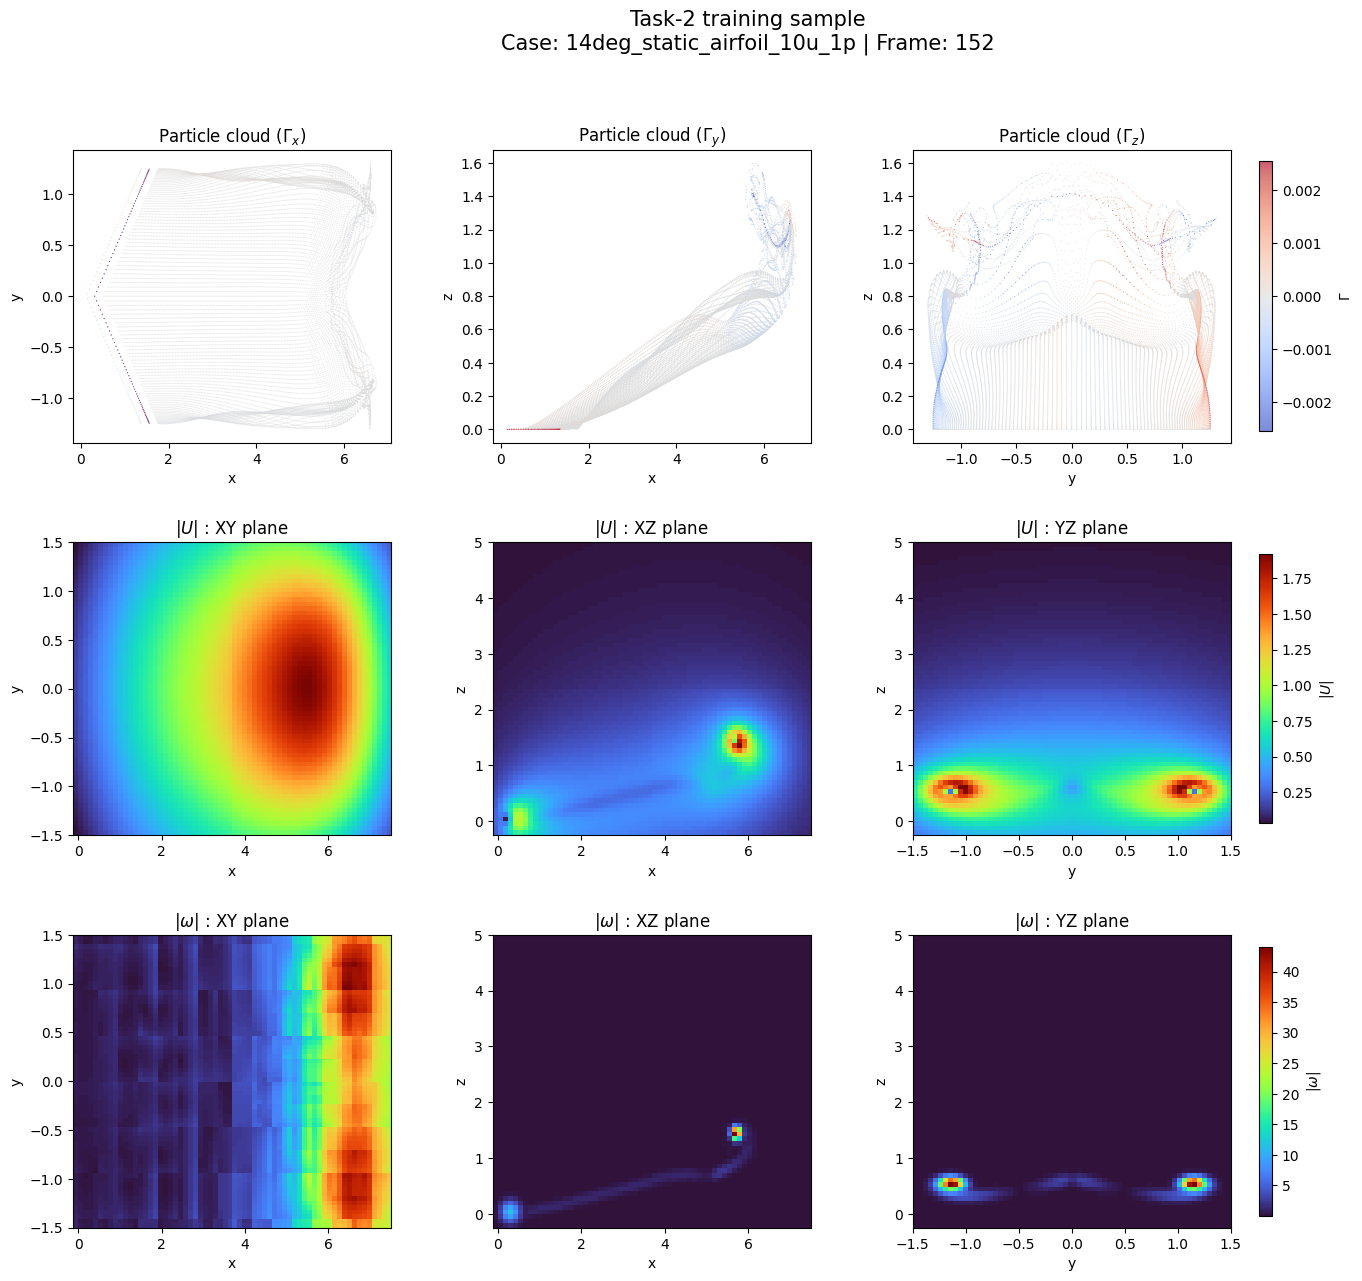

In [53]:
def save_fig(fig, name, dpi=300):
    out = RESULTS_DIR / f"{CFG['file_tag']}_{name}"
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print('[saved]', out)


def plot_io_sample(
    dataset,
    title='Task-2 sample',
    sample_index=110,
    max_particles=50000,
):

    item = dataset[sample_index]

    fid = int(item['frame_id'].item())

    path = sample_paths[fid]

    with np.load(path, allow_pickle=True) as d:

        in_xyz = np.asarray(d['input_geom'], dtype=np.float32)

        features = np.asarray(d['input_features'], dtype=np.float32)

        out_xyz = np.asarray(d['output_queries'], dtype=np.float32)

        targets = np.asarray(d['targets'], dtype=np.float32)

    # ==========================================================
    # PARTICLE FEATURES
    # ==========================================================

    gamma_x = features[:, 3]
    gamma_y = features[:, 4]
    gamma_z = features[:, 5]

    velocity_mag = np.linalg.norm(targets[:, :3], axis=1)

    vorticity_mag = np.linalg.norm(targets[:, 3:6], axis=1)

    # ==========================================================
    # PARTICLE SUBSAMPLING FOR VISUALIZATION
    # ==========================================================

    pidx = sample_indices(
        len(in_xyz),
        max_particles,
        SEED + fid
    )

    in_xyz_plot = in_xyz[pidx]

    # ==========================================================
    # GRID RESHAPING
    # ==========================================================

    Nx, Ny, Nz = grid_resolution

    X = out_xyz[:, 0].reshape(Nx, Ny, Nz)
    Y = out_xyz[:, 1].reshape(Nx, Ny, Nz)
    Z = out_xyz[:, 2].reshape(Nx, Ny, Nz)

    U = velocity_mag.reshape(Nx, Ny, Nz)
    W = vorticity_mag.reshape(Nx, Ny, Nz)

    ix = Nx // 2
    iy = Ny // 2
    iz = Nz // 2

    # ==========================================================
    # FIGURE
    # ==========================================================

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(18, 14)
    )

    fig.subplots_adjust(
        wspace=0.32,
        hspace=0.34
    )

    # ==========================================================
    # PARTICLE CLOUD PROJECTIONS
    # ==========================================================

    projection_views = [
        (0, 1, 'x', 'y'),
        (0, 2, 'x', 'z'),
        (1, 2, 'y', 'z'),
    ]

    gamma_components = [
        (gamma_x, r'$\Gamma_x$'),
        (gamma_y, r'$\Gamma_y$'),
        (gamma_z, r'$\Gamma_z$'),
    ]

    for ax, ((component, label), (i, j, xi, xj)) in zip(
        axes[0],
        zip(gamma_components, projection_views)
    ):

        vmax = np.percentile(
            np.abs(component[pidx]),
            99
        )

        sc = ax.scatter(
            in_xyz_plot[:, i],
            in_xyz_plot[:, j],
            c=component[pidx],
            s=0.7,
            cmap='coolwarm',
            vmin=-vmax,
            vmax=vmax,
            alpha=0.65,
            linewidths=0,
        )

        ax.set_xlabel(xi)
        ax.set_ylabel(xj)

        ax.set_title(
            rf'Particle cloud ({label})'
        )

        ax.set_aspect('auto')

    cbar_particles = fig.colorbar(
        sc,
        ax=axes[0],
        shrink=0.92,
        pad=0.02
    )

    cbar_particles.set_label(r'$\Gamma$')

    # ==========================================================
    # VELOCITY FIELD
    # ==========================================================

    im0 = axes[1, 0].imshow(
        U[:, :, iz].T,
        origin='lower',
        extent=[
            X[:, :, iz].min(),
            X[:, :, iz].max(),
            Y[:, :, iz].min(),
            Y[:, :, iz].max(),
        ],
        cmap='turbo',
        aspect='auto'
    )

    axes[1, 0].set_title(r'$|U|$ : XY plane')

    axes[1, 0].set_xlabel('x')
    axes[1, 0].set_ylabel('y')

    im1 = axes[1, 1].imshow(
        U[:, iy, :].T,
        origin='lower',
        extent=[
            X[:, iy, :].min(),
            X[:, iy, :].max(),
            Z[:, iy, :].min(),
            Z[:, iy, :].max(),
        ],
        cmap='turbo',
        aspect='auto'
    )

    axes[1, 1].set_title(r'$|U|$ : XZ plane')

    axes[1, 1].set_xlabel('x')
    axes[1, 1].set_ylabel('z')

    im2 = axes[1, 2].imshow(
        U[ix, :, :].T,
        origin='lower',
        extent=[
            Y[ix, :, :].min(),
            Y[ix, :, :].max(),
            Z[ix, :, :].min(),
            Z[ix, :, :].max(),
        ],
        cmap='turbo',
        aspect='auto'
    )

    axes[1, 2].set_title(r'$|U|$ : YZ plane')

    axes[1, 2].set_xlabel('y')
    axes[1, 2].set_ylabel('z')

    cbar_velocity = fig.colorbar(
        im2,
        ax=axes[1],
        shrink=0.92,
        pad=0.02
    )

    cbar_velocity.set_label(r'$|U|$')

    # ==========================================================
    # VORTICITY FIELD
    # ==========================================================

    im3 = axes[2, 0].imshow(
        W[:, :, iz].T,
        origin='lower',
        extent=[
            X[:, :, iz].min(),
            X[:, :, iz].max(),
            Y[:, :, iz].min(),
            Y[:, :, iz].max(),
        ],
        cmap='turbo',
        aspect='auto'
    )

    axes[2, 0].set_title(r'$|\omega|$ : XY plane')

    axes[2, 0].set_xlabel('x')
    axes[2, 0].set_ylabel('y')

    im4 = axes[2, 1].imshow(
        W[:, iy, :].T,
        origin='lower',
        extent=[
            X[:, iy, :].min(),
            X[:, iy, :].max(),
            Z[:, iy, :].min(),
            Z[:, iy, :].max(),
        ],
        cmap='turbo',
        aspect='auto'
    )

    axes[2, 1].set_title(r'$|\omega|$ : XZ plane')

    axes[2, 1].set_xlabel('x')
    axes[2, 1].set_ylabel('z')

    im5 = axes[2, 2].imshow(
        W[ix, :, :].T,
        origin='lower',
        extent=[
            Y[ix, :, :].min(),
            Y[ix, :, :].max(),
            Z[ix, :, :].min(),
            Z[ix, :, :].max(),
        ],
        cmap='turbo',
        aspect='auto'
    )

    axes[2, 2].set_title(r'$|\omega|$ : YZ plane')

    axes[2, 2].set_xlabel('y')
    axes[2, 2].set_ylabel('z')

    cbar_vorticity = fig.colorbar(
        im5,
        ax=axes[2],
        shrink=0.92,
        pad=0.02
    )

    cbar_vorticity.set_label(r'$|\omega|$')

    # ==========================================================
    # TITLE
    # ==========================================================

    context = context_dict(fid)

    fig.suptitle(
        (
            f'{title}\n'
            f'Case: {context["case"]} | '
            f'Frame: {context["frame"]}'
        ),
        fontsize=15,
        y=0.98
    )

    # ==========================================================
    # SAVE + SHOW
    # ==========================================================

    save_fig(
        fig,
        'io_sample_multiview.png'
    )

    plt.show()


plot_io_sample(
    train_ds,
    title='Task-2 training sample'
)

Normalized Values Distribution of Output Fields

In [8]:
def make_latent_queries(res, device):
    line = torch.linspace(0.0, 1.0, int(res), dtype=torch.float32, device=device)
    xx, yy, zz = torch.meshgrid(line, line, line, indexing='ij')
    return torch.stack([xx, yy, zz], dim=-1).unsqueeze(0)

LATENT_QUERIES = make_latent_queries(CFG['latent_res'], DEVICE)


def build_model(cfg):
    if GINO is None:
        raise RuntimeError(
            'neuralop.models.GINO is not available in this kernel. '
            'Install NeuralOperator with `pip install neuraloperator`, then restart the kernel.'
        ) from GINO_IMPORT_ERROR

    kwargs = dict(
        in_channels=len(feature_names),
        out_channels=len(target_names),
        gno_coord_dim=3,
        in_gno_radius=cfg['in_gno_radius'],
        out_gno_radius=cfg['out_gno_radius'],
        in_gno_transform_type=cfg['in_gno_transform_type'],
        out_gno_transform_type=cfg['out_gno_transform_type'],
        gno_embed_channels=cfg['gno_embed_channels'],
        gno_use_open3d=cfg['gno_use_open3d'],
        gno_use_torch_scatter=cfg['gno_use_torch_scatter'],
        fno_n_modes=tuple(cfg['fno_n_modes']),
        fno_hidden_channels=cfg['fno_hidden_channels'],
        fno_n_layers=cfg['fno_n_layers'],
        projection_channel_ratio=cfg['projection_channel_ratio'],
    )

    signature = inspect.signature(GINO)
    accepted = set(signature.parameters)
    filtered = {k: v for k, v in kwargs.items() if k in accepted}
    dropped = sorted(set(kwargs) - set(filtered))
    if dropped:
        print('[info] Dropping GINO kwargs not accepted by this neuralop version:', dropped)

    return GINO(**filtered).to(DEVICE)

MODEL = build_model(CFG)
TOTAL_PARAMS = count_model_params(MODEL)
TRAINABLE_PARAMS = sum(p.numel() for p in MODEL.parameters() if p.requires_grad)
print('Latent queries:', tuple(LATENT_QUERIES.shape))
print('Total params:', f'{TOTAL_PARAMS:,}')
print('Trainable params:', f'{TRAINABLE_PARAMS:,}')

Latent queries: (1, 8, 8, 8, 3)
Total params: 410,583
Trainable params: 327,639


In [9]:
target_mean_t = torch.tensor(target_mean, dtype=torch.float32, device=DEVICE).view(1, 1, -1)
target_std_t = torch.tensor(target_std, dtype=torch.float32, device=DEVICE).view(1, 1, -1)


def move_batch(batch):
    return {k: (v.to(DEVICE, non_blocking=True) if torch.is_tensor(v) else v) for k, v in batch.items()}


def predict(model, batch):
    return model(
        input_geom=batch['input_geom'],
        latent_queries=LATENT_QUERIES,
        output_queries=batch['output_queries'],
        x=batch['x'],
    )


def denormalize_target(y_norm):
    return y_norm * target_std_t + target_mean_t


def relative_l2(pred, target, eps=1e-12):
    diff = (pred - target).reshape(pred.shape[0], -1)
    ref = target.reshape(target.shape[0], -1)
    return torch.linalg.norm(diff, dim=1) / torch.linalg.norm(ref, dim=1).clamp_min(eps)


def weighted_training_loss(pred, target):
    vel_loss = torch.mean((pred[..., :3] - target[..., :3]) ** 2)
    vort_loss = torch.mean((pred[..., 3:] - target[..., 3:]) ** 2)
    return vel_loss + vort_loss, vel_loss.detach(), vort_loss.detach()


@torch.no_grad()
def evaluate(model, loader, collect=False):
    model.eval()
    if len(loader.dataset) == 0:
        return {'loss': math.nan, 'rel_l2_norm': math.nan, 'rel_l2_phys': math.nan, 'rmse_phys': math.nan, 'mae_phys': math.nan, 'rel_per_sample': np.asarray([], dtype=np.float32)}
    sums = defaultdict(float)
    rels = []
    n = 0
    for batch in loader:
        batch = move_batch(batch)
        pred = predict(model, batch)
        y = batch['y']
        loss, _, _ = weighted_training_loss(pred, y)
        pred_phys = denormalize_target(pred)
        y_phys = denormalize_target(y)
        rel_norm = relative_l2(pred, y)
        rel_phys = relative_l2(pred_phys, y_phys)
        rmse_phys = torch.sqrt(torch.mean((pred_phys - y_phys) ** 2))
        mae_phys = torch.mean(torch.abs(pred_phys - y_phys))
        sums['loss'] += float(loss.item())
        sums['rel_l2_norm'] += float(rel_norm.mean().item())
        sums['rel_l2_phys'] += float(rel_phys.mean().item())
        sums['rmse_phys'] += float(rmse_phys.item())
        sums['mae_phys'] += float(mae_phys.item())
        if collect:
            rels.extend(rel_phys.detach().cpu().numpy().tolist())
        n += 1
    out = {k: v / max(n, 1) for k, v in sums.items()}
    if collect:
        out['rel_per_sample'] = np.asarray(rels, dtype=np.float32)
    return out

In [10]:
optimizer = torch.optim.AdamW(MODEL.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
try:
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda' and CFG['use_amp']))
except TypeError:
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda' and CFG['use_amp']))
autocast_options = dict(device_type=DEVICE.type, enabled=(DEVICE.type == 'cuda' and CFG['use_amp']))

history = {
    'epoch': [], 'train_loss': [], 'train_rel_l2_norm': [], 'train_velocity_loss': [], 'train_vorticity_loss': [],
    'val_id_rel_l2_phys': [], 'val_angle_rel_l2_phys': [], 'test_rel_l2_phys': [], 'test_rmse_phys': [],
    'lr': [], 'bad_batches': [], 'optimizer_steps': [],
}

best_score = float('inf')

for epoch in range(1, CFG['epochs'] + 1):
    MODEL.train()
    start_time = time.time()
    accumulation_steps = max(int(CFG['gradient_accumulation_steps']), 1)
    optimizer.zero_grad(set_to_none=True)

    train_losses, train_rels, vel_losses, vort_losses = [], [], [], []
    bad_batches = 0
    optimizer_steps = 0

    for local_step, batch in enumerate(train_loader, start=1):
        batch = move_batch(batch)
        with torch.autocast(**autocast_options):
            pred = predict(MODEL, batch)
            loss, vel_loss, vort_loss = weighted_training_loss(pred, batch['y'])
            loss_for_backward = loss / accumulation_steps

        if not torch.isfinite(loss):
            bad_batches += 1
            optimizer.zero_grad(set_to_none=True)
            continue

        if scaler.is_enabled():
            scaler.scale(loss_for_backward).backward()
        else:
            loss_for_backward.backward()

        should_step = local_step % accumulation_steps == 0 or local_step == len(train_loader)
        if should_step:
            if scaler.is_enabled():
                scaler.unscale_(optimizer)
            if CFG['grad_clip_norm'] is not None and CFG['grad_clip_norm'] > 0:
                torch.nn.utils.clip_grad_norm_(MODEL.parameters(), CFG['grad_clip_norm'])
            if scaler.is_enabled():
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            optimizer_steps += 1

        with torch.no_grad():
            train_losses.append(float(loss.item()))
            train_rels.append(float(relative_l2(pred, batch['y']).mean().item()))
            vel_losses.append(float(vel_loss.item()))
            vort_losses.append(float(vort_loss.item()))

    scheduler.step()

    if epoch % CFG['eval_every'] == 0:
        val_id_metrics = evaluate(MODEL, val_id_loader)
        val_angle_metrics = evaluate(MODEL, val_angle_loader)
        test_metrics = evaluate(MODEL, test_loader)
        train_loss = float(np.mean(train_losses))
        train_rel = float(np.mean(train_rels))
        score = val_id_metrics['rel_l2_phys']
        if not np.isfinite(score):
            score = val_angle_metrics['rel_l2_phys'] if np.isfinite(val_angle_metrics['rel_l2_phys']) else test_metrics['rel_l2_phys']

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_rel_l2_norm'].append(train_rel)
        history['train_velocity_loss'].append(float(np.mean(vel_losses)))
        history['train_vorticity_loss'].append(float(np.mean(vort_losses)))
        history['val_id_rel_l2_phys'].append(val_id_metrics['rel_l2_phys'])
        history['val_angle_rel_l2_phys'].append(val_angle_metrics['rel_l2_phys'])
        history['test_rel_l2_phys'].append(test_metrics['rel_l2_phys'])
        history['test_rmse_phys'].append(test_metrics['rmse_phys'])
        history['lr'].append(float(optimizer.param_groups[0]['lr']))
        history['bad_batches'].append(int(bad_batches))
        history['optimizer_steps'].append(int(optimizer_steps))

        if np.isfinite(score) and score < best_score:
            best_score = float(score)
            torch.save({
                'model_state_dict': MODEL.state_dict(),
                'config': dict(CFG),
                'feature_names': feature_names,
                'target_names': target_names,
                'active_input_feature_indices': active_input_feature_indices,
                'removed_input_features': removed_input_features,
                'dataset_path': str(DATASET_PATH),
                'grid_resolution': grid_resolution,
                'coord_min': coord_min,
                'coord_span': coord_span,
                'input_mean': input_mean,
                'input_std': input_std,
                'target_mean': target_mean,
                'target_std': target_std,
                'best_score': best_score,
                'history': history,
            }, CKPT_PATH)
            HISTORY_PATH.write_text(json.dumps(history, indent=2))

        elapsed = time.time() - start_time
        print(
            f"[{epoch:03d}] train_loss={train_loss:.4e} train_rel={train_rel:.4e} "
            f"val_id={val_id_metrics['rel_l2_phys']:.4e} val_angle={val_angle_metrics['rel_l2_phys']:.4e} "
            f"test={test_metrics['rel_l2_phys']:.4e} rmse={test_metrics['rmse_phys']:.4e} "
            f"bad={bad_batches} steps={optimizer_steps} lr={history['lr'][-1]:.2e} time={elapsed:.1f}s"
        )

print('Best score:', best_score)
print('Saved checkpoint:', CKPT_PATH)
HISTORY_PATH.write_text(json.dumps(history, indent=2))

[005] train_loss=1.6339e+00 train_rel=8.9299e-01 val_id=9.5786e-01 val_angle=9.5747e-01 test=9.4951e-01 rmse=1.5843e+00 bad=0 steps=110 lr=2.80e-04 time=111.3s
[010] train_loss=1.5766e+00 train_rel=8.7528e-01 val_id=9.5196e-01 val_angle=9.5045e-01 test=9.4155e-01 rmse=1.5710e+00 bad=0 steps=110 lr=2.25e-04 time=112.2s
[015] train_loss=1.5572e+00 train_rel=8.6904e-01 val_id=9.4953e-01 val_angle=9.4734e-01 test=9.3890e-01 rmse=1.5667e+00 bad=0 steps=110 lr=1.50e-04 time=111.6s
[020] train_loss=1.5463e+00 train_rel=8.6580e-01 val_id=9.4759e-01 val_angle=9.4529e-01 test=9.3699e-01 rmse=1.5634e+00 bad=0 steps=110 lr=7.50e-05 time=112.4s
[025] train_loss=1.5401e+00 train_rel=8.6400e-01 val_id=9.4775e-01 val_angle=9.4514e-01 test=9.3682e-01 rmse=1.5626e+00 bad=0 steps=110 lr=2.01e-05 time=113.5s
[030] train_loss=1.5382e+00 train_rel=8.6353e-01 val_id=9.4702e-01 val_angle=9.4445e-01 test=9.3633e-01 rmse=1.5620e+00 bad=0 steps=110 lr=0.00e+00 time=113.4s
Best score: 0.9470192649147727
Saved che

1744

In [11]:
# Load the best checkpoint and run final split metrics.
try:
    checkpoint = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)

MODEL.load_state_dict(checkpoint['model_state_dict'])
MODEL.eval()

FINAL_METRICS = {
    'train_sampled': evaluate(MODEL, train_loader, collect=True),
    'val_id': evaluate(MODEL, val_id_loader, collect=True),
    'val_angle': evaluate(MODEL, val_angle_loader, collect=True),
    'test': evaluate(MODEL, test_loader, collect=True),
}
for split, metrics in FINAL_METRICS.items():
    print(f"{split:12s} rel-L2={metrics['rel_l2_phys']:.4e} RMSE={metrics['rmse_phys']:.4e} MAE={metrics['mae_phys']:.4e}")

train_sampled rel-L2=9.4051e-01 RMSE=1.1008e+00 MAE=1.6920e-01
val_id       rel-L2=9.4702e-01 RMSE=1.1630e+00 MAE=1.7012e-01
val_angle    rel-L2=9.4445e-01 RMSE=1.0400e+00 MAE=1.5083e-01
test         rel-L2=9.3633e-01 RMSE=1.5620e+00 MAE=2.3266e-01
